In [1]:
pip install pandas matplotlib wordcloud nltk

Note: you may need to restart the kernel to use updated packages.


## Load Data

In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\vedant\Downloads\Challenge 2_Feedback.csv')
text = df['text'].dropna()

In [4]:
df.head()

,id,text
0,1,Nothing in the charge breakdown felt sneaky. T...
1,2,One thing that dragged it down was that I wait...
2,3,There was enough padding around the contents a...
3,4,What shaped my score most was that the shipmen...
4,5,The condition notes were thinner than they sho...


### Cleaning text

In [5]:
import re

def clean_text(t):
    t = t.lower()
    t = re.sub(r'[^a-z\s]', '', t)
    return t

text = text.apply(clean_text)

### Removing stopwords and some insignificant words

In [36]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
custom_stopwords = set([
    'felt','score','experience','overall','like','made','part','well',
    'good','real','expected','buying','purchase','item','auction','bid','came','lots','process','shaped','online','smooth','whole','uncertainity','value','feel','could','needed','clear','whetehr','took','think','ended','easy','somewhere','matters','people','tends',
    'would','gave','even','fact','something','view','become','feels','much','cannot','already','matter','kept','mind','really','away','looked','time','whether','side','points','things','lot','important','make','person','see','middle',
    'bit','little','small','stopped','stil','reason','effect','kind','without','got','left','aceept','one','drove','end','feeling','around','normal','better','disappointing',
    'mixed','harder','pulled','way','sense','strong','helped''marked','worked','pretty','thing','seemed','right','point','less','start','finish','rather','weak','although','rate','highly','line','nothing','wanted','understand','following','fully','get','thought','gone','win','internal','showed',
    'enough','difference','impression','journey','inspect','top','bad','still','hard','positives','big','total','short','comfortable','higher','fine','changes','basics','friction','accept','fairly','realistic','happy','negatives','avoidable','clearly','final','fair','decent','mattered',
    'worth','long','helped','marked','quickly','outweighed','rated','paying','lower','easier','problem','longer','resonable','prepared','obvious','matched','worst','became','page','appear','finding','suggested','judge','dragged','actual','placing','instead','keep','generic','next',
    'high','received','always','items','opened','basic','come','submitting','piece','pushed','honest','hand','liked','unsure','excessive','job','find','wrong',
    'carefully','surprised','genuinely','narrow','turned','inside','hoped','hesitate','behaved','case','laid','excited','question','honestly','pages','inspire','reasons','frustratingly','care','far','followed',
    'reduced','planned','stay','picked','especially','closed','bought','trying','affected','downside','sound','proportionate','never','winning','listed','reduced','planned','weakest','weaker','likely','pleasantly','since','professionally',
    'stage','lowered','heated','seeing','chase','window','staying','wore','along','surprises','knew','heavier','number','life','ignore','use','necessary','led','expect','changed','room','overdoing','twice',
    'using', 'sooner', 'late','arrive', 'sent','makes','ready','held','found','despite','minimal','fuss','involved','reacted', 'jumping' ,'hoops', 'mainly', 'many', 'definitely','potential','becoming','climbed','past','everything','go','seriously','tense','anxious','enjoy','reached','exposed','repeatedly','want','happily','key','keeps','avoided','main','cleanly','busy','stayed','questioning','increased','chance','moments','meant','soon','pleased','faded','similar','ran','note','wondering','happening','open','keeping','place','ususal','sight','alive','stuck','seem','rely','decide','manually','often','glad','getting','exactly',
    'confidence','landed'
    
])

stop_words = set(stopwords.words('english')).union(custom_stopwords)

text = text.apply(lambda x: " ".join([word for word in x.split() if word not in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vedant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Most frequent words

In [37]:
from collections import Counter

all_words = " ".join(text).split()
word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('details', 273), ('uncertainty', 216), ('platform', 193), ('payment', 175), ('rating', 171), ('delivery', 165), ('bidding', 158), ('shipping', 154), ('shape', 146), ('watching', 135), ('price', 127), ('auctions', 126), ('support', 125), ('account', 125), ('arrived', 120), ('handled', 119), ('format', 116), ('condition', 112), ('highrisk', 112), ('clarity', 112)]


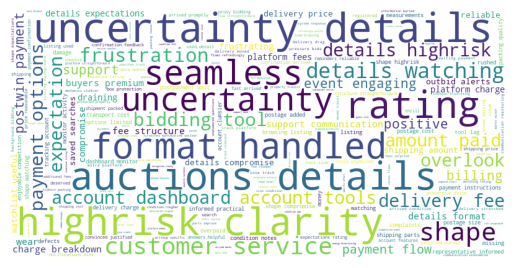

In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))

plt.imshow(wc)
plt.axis('off')
plt.show()